# Agenda

SVMs and SVC - Concepts

SVC - Code demo

Significance of different kernels in SVC

Comparision of SVC with Logistic Reg

SVR - Concepts

SVR - Code demo

GridSearchCV and RandomizedSearchCV


# Support Vector Clasification - Concepts

Imagine you have a bunch of red and blue toy blocks scattered on a table. Your job is to separate the red blocks from the blue blocks using a big ruler. 

<b> The Goal </b>: You could use many different rulers to separate the blocks, but you want to find the best one. The "equation" in SVM is not a single formula, but rather an optimization problem with a specific objective function and set of constraints. The goal is to find the optimal hyperplane that separates the data with the maximum margin. 

<ol>
<i> Widest "street": The SVM algorithm looks for the ruler that creates the widest possible "street" between the red and blue blocks. The ruler is the middle of the street. This wide street gives you the most room for error, so you can be confident that even if you get new blocks, they'll land on the correct side. </i>

Special blocks: The blocks that are closest to the edges of this "street" are the most important ones. They are called support vectors. The ruler's position is determined by these special blocks, not by all the other blocks that are far away.

Bending the street: What if the blocks are jumbled up in a way that you can't use a straight ruler? SVM is super clever! It can "lift" the blocks into a higher dimension, like into the air above the table. In this new space, you can use a flat board (a plane) to easily separate them. When you put the blocks back on the table, that flat board becomes a curvy line, perfectly separating the red and blue blocks. This clever trick is called the kernel trick. 
</ol>


<img src="./images/svm_1.webp" alt="sample" width="1000"/>

<img src="./images/svm_2.jpg" alt="sample" width="1000"/>

<img src="./images/svm_4.jpg" alt="sample" width="1000"/>

<h2> Hyperparameters </h2>

The primary hyperparameters for a Support Vector Machine (SVM) model are C, kernel, and gamma. 

<b> C is like a strictness knob </b>

<ol>
Low C (Less Strict): The model is more tolerant of mistakes, building a wider, simpler "street" between the data points. This can lead to underfitting if the street is too wide.
    
High C (More Strict): The model is less tolerant of mistakes, forcing the "street" to be narrower to classify every training point correctly. This can cause the model to overfit to noisy data.
<ol>

The <b> kernel parameter </b> specifies the function that transforms the input data into a higher-dimensional space to make it linearly separable. The choice of kernel is crucial for handling non-linear data.

<ol>
Common Kernel Functions:

Linear: The simplest kernel, used when data is already linearly separable. This is equivalent to having no kernel trick at all.

Radial Basis Function (RBF): The most popular and versatile kernel. It creates a non-linear decision boundary that can handle complex data.

Polynomial: A non-linear kernel that creates a polynomial decision boundary.

Sigmoid: Another non-linear kernel that can perform well in certain situations. 

<ol>

<b> Gamma (Kernel Coefficient) </b>

<ol>
What it does: The gamma parameter defines how far the influence of a single training example (a support vector) reaches. It is used with non-linear kernels like RBF, polynomial, and sigmoid.

gamma is like a spotlight on the support vectors.

Low Gamma: The spotlight is wide, meaning the influence of each support vector is far-reaching. This results in a smoother, less complex decision boundary, and may lead to underfitting.

High Gamma: The spotlight is narrow, meaning the influence of each support vector is close-range. This creates a more complex, wiggly decision boundary that tries to fit every data point perfectly, which can cause overfitting.

</ol>

<b> The "right" hyperparameters </b>

<ol>

A high gamma with a low C can produce a very complex, non-linear boundary that still tolerates some misclassifications, leading to a balanced model.

A low gamma with a high C can create a smoother boundary that is still forced to try and classify all points correctly, making it less robust. 

</ol>

<img src="./images/svm_3.jpg" alt="sample" width="1000"/>

<img src="./images/svm_5.webp" alt="sample" width="1000"/>

# Code example - Support Vector Classification

In [ ]:
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load Breast Cancer dataset
cancer = datasets.load_breast_cancer()
X = cancer.data
y = cancer.target

# Convert to DataFrame (optional, for exploration)
df = pd.DataFrame(X, columns=cancer.feature_names)
df["target"] = y
print(df.head())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling (very important for SVC)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVC model
svc = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svc.fit(X_train_scaled, y_train)

# Predictions
y_pred = svc.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=cancer.target_names))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(svc, X_test_scaled, y_test, cmap="Blues")
plt.show()

# Significance of different kernels in SVC

Many datasets (Wine, Breast Cancer, Iris) are not linearly separable.

A simple linear kernel would fail to capture complex class boundaries.

In Breast Cancer dataset, features are correlated and decision boundary is not perfectly linear.

Using rbf often gives higher accuracy than linear.

In [ ]:
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load Breast Cancer dataset
cancer = datasets.load_breast_cancer()
X, y = cancer.data, cancer.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (very important for SVMs!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define different kernels
kernels = ["linear", "rbf", "poly"]

results = {}

for k in kernels:
    svc = SVC(kernel=k, C=1.0, gamma="scale", degree=3, random_state=42)
    svc.fit(X_train_scaled, y_train)
    y_pred = svc.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    results[k] = {
        "accuracy": acc,
        "report": classification_report(
            y_test, y_pred, target_names=cancer.target_names, zero_division=0
        )
    }

# Show results
for k, res in results.items():
    print("="*50)
    print(f"Kernel: {k.upper()}")
    print(f"Accuracy: {res['accuracy']:.4f}")
    print(res["report"])

# Logistic regression vs Support vector classification

Choose Logistic Regression when:

<ol>
Interpretability is key for explaining results to stakeholders.
    
You need well-calibrated probability scores.

Your dataset is large and you need a computationally efficient solution.

The data is roughly linearly separable.
</ol>

Choose SVC when:

<ol>
    
The data is not linearly separable, and you can use the kernel trick to handle non-linear boundaries.

You have a high-dimensional feature space and a modest number of samples.

Maximum predictive accuracy is the primary goal, even at the cost of interpretability and computational expense.

The data has complex relationships and outliers are not a major concern near the decision boundary. 

</ol>

In [ ]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("./images/Comparision_between_SVC_and_LR.csv")

# Show all columns without truncation
pd.set_option("display.max_columns", None)   # show all columns
pd.set_option("display.max_colwidth", None)  # don't truncate column values
pd.set_option("display.width", None)         # let pandas decide based on notebook width

from IPython.display import display

display(df)

LogReg   acc: 0.863 ± 0.032
SVC (RBF) acc: 0.903 ± 0.024


/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


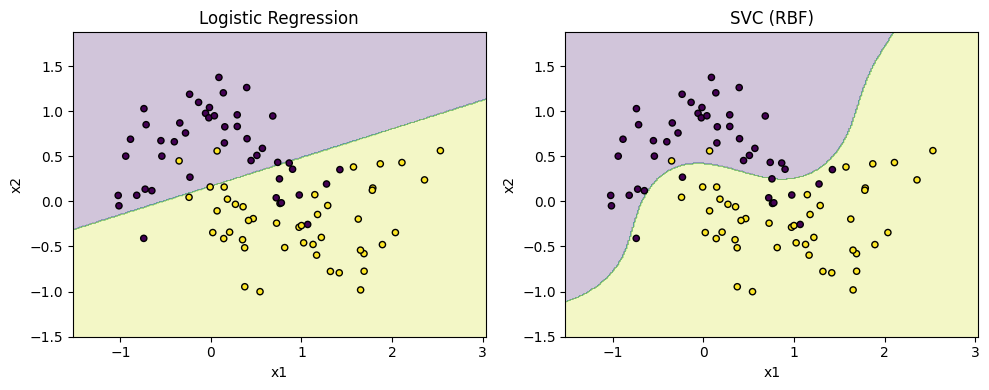

In [1]:
# pip install scikit-learn matplotlib
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# 1) Small non-linear dataset
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

# 2) Same preprocessing for both models
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

svc_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

# 3) Quick 5-fold CV comparison
scores_lr  = cross_val_score(log_reg, X, y, cv=5, scoring="accuracy")
scores_svc = cross_val_score(svc_rbf, X, y, cv=5, scoring="accuracy")
print(f"LogReg   acc: {scores_lr.mean():.3f} ± {scores_lr.std():.3f}")
print(f"SVC (RBF) acc: {scores_svc.mean():.3f} ± {scores_svc.std():.3f}")

# 4) Train once and visualize decision boundaries
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
log_reg.fit(Xtr, ytr)
svc_rbf.fit(Xtr, ytr)

def plot_decision_boundary(model, X, y, title):
    # Create grid
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    # Predict on grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    # Plot
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:,0], X[:,1], c=y, s=20, edgecolor="k")
    plt.title(title)
    plt.xlabel("x1"); plt.ylabel("x2")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plot_decision_boundary(log_reg, Xte, yte, "Logistic Regression")
plt.subplot(1,2,2); plot_decision_boundary(svc_rbf, Xte, yte, "SVC (RBF)")
plt.tight_layout(); plt.show()

# Support Vector Regressor - Concepts

Think of a playground with a slide. Your job is to find the best angle for the slide so that most kids can use it. You have a bunch of kids of different heights.

<b>The Goal</b>: You don't need the slide to perfectly match every single kid's height. You just need it to be in a good, general position so that most kids can use it without it being too high or too low for them.

<b> How SVR finds the best slide angle: </b>

<ol>
The "sweet spot" tube: SVR draws a wide tube (the "sweet spot" of the slide) where it expects most kids to be. The width of this tube is called <b>epsilon</b>.  Any kids that are inside this tube are considered a good fit, so we don't worry about them.

From the algorithm's perspective, these kids' positions are not important for determining the slide's angle. 

Now, imagine there are a few very tall or very short kids who are way outside this tube. These are our outliers.

Penalizing the outliers: The only kids that matter are the ones who are way too tall or way too short and end up outside the tube. The SVR algorithm will adjust the angle of the slide to minimize how far these outlier kids are from the tube. These important outlier kids are our support vectors.

In linear regression, every single kid's distance from the slide affects its angle, and these few outliers could dramatically pull the slide out of a good position for everyone else. 

SVR's optimization function (its core mathematical goal) is designed to minimize the distance of these outliers from the edge of the tube.

The farther an outlier is from the tube, the higher the penalty for that outlier. This makes the algorithm work to reduce that penalty by adjusting the slide's angle.

Crucially, the algorithm doesn't care about the error for the points inside the tube. It only focuses on the penalty from the points outside. 

The outliers that fall outside the tube are the support vectors. These are the special data points that define the final position of the slide.

The soft, wiggly slide: If the kids are not in a straight line, SVR can use a clever trick (the kernel trick) to make the slide a nice, curvy shape that follows the general flow of the kids. 

SVR uses the weighted sum of support vectors to determine the new data point.

<ol>

The epsilon parameter defines the width of the slide's "sweet spot" tube.

The slack variable is the specific measurement of how far a kid is from the edge of the tube.

A kid perfectly inside the tube has a slack of 0.

A kid far away from the tube has a large slack, and the algorithm tries to adjust the slide to reduce that slack, but only as much as the C parameter allows. 

So, while the epsilon parameter sets the acceptable range of error, the slack variable is the precise way SVR quantifies the violations outside that range. 


<img src="./images/svm_6.png" alt="sample" width="1000"/>

### Hyperparameters

<b> C (Regularization Parameter) </b>

What it does: Controls the penalty for errors. It determines the trade-off between keeping the regression line as flat as possible and tolerating errors that fall outside the epsilon-insensitive tube.

Small C: The model is more tolerant of errors and prioritizes a flatter regression line. This helps prevent overfitting, especially with noisy data.

Large C: The model is less tolerant of errors and will choose a more complex line to minimize violations outside the tube, which can lead to overfitting. 

<b> Epsilon </b>

What it does: This parameter defines the width of the tube around the regression line where no penalty is associated with errors. Any data points inside this tube are considered correctly predicted.

Small epsilon : Forces the model to fit the training data more tightly, potentially capturing more noise and leading to overfitting.

Large epsilon : Allows for more data points to be within the tube, resulting in a smoother, more generalized model. It can lead to underfitting if the tube is too wide. 

<b> kernel </b>

Linear, RBF, Polynomial

<b> gamma </b>

low gamma, high gamma

# Code example - Support Vector Regressor

In [2]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Load California housing dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Convert to DataFrame (optional for inspection)
df = pd.DataFrame(X, columns=housing.feature_names)
df["target"] = y
print(df.head())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for SVR!)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Reshape y before scaling (since it's 1D)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

# Train SVR with RBF kernel
svr = SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1)
svr.fit(X_train_scaled, y_train_scaled)

# Predictions (remember to inverse scale)
y_pred_scaled = svr.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  
Root Mean Squared Error (RMSE): 0.5714470799143132
R² Score: 0.7508016424147518


# Using GridSearchCV

GridSearchCV is a technique for finding the best combination of hyperparameters for a machine learning model. It systematically works through multiple combinations of user-specified hyperparameter values, evaluating each one and returning the one that performs the best. 

1)  Define a "grid": You provide a machine learning model and a dictionary of hyperparameters with a list of values to test for each one. For example, for a Support Vector Machine (SVM), you might specify a grid for C as [0.1, 1.0, 10.0] and kernel as ['linear', 'rbf'].


2)  Exhaustive search: GridSearchCV will then evaluate every possible combination. In the SVM example above, it will check six combinations: C=0.1, kernel='linear', C=0.1, kernel='rbf', C=1.0, kernel='linear', C=1.0, kernel='rbf', C=10.0, kernel='linear' and C=10.0, kernel='rbf'

3)  Cross-validation (CV): For each of these combinations, GridSearchCV uses cross-validation to assess the model's performance. This involves splitting your training data into multiple "folds," training the model on some of the folds, and evaluating it on the remaining one. This process is repeated until each fold has been used as the test set.

4)  Performance evaluation: After testing all combinations, GridSearchCV identifies the one that yielded the best average performance based on a chosen metric (like accuracy or F1-score) and returns the model with those optimal hyperparameters. 

Disadvantages:

Can be computationally very expensive


In [3]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load California housing dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target

# (Optional) Inspect
df = pd.DataFrame(X, columns=housing.feature_names)
df["target"] = y
print(df.head())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline: scale X, fit SVR; wrap with TransformedTargetRegressor to scale y
x_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])

model = TransformedTargetRegressor(
    regressor=x_pipe,
    transformer=StandardScaler()  # scales y internally; inverse-transform on predict
)

# Param grid targets the inner SVR hyperparameters
param_grid = {
    "regressor__svr__C":      [1, 10, 100, 1000],
    "regressor__svr__gamma":  [1e-3, 1e-2, 1e-1, "scale"],
    "regressor__svr__epsilon":[0.01, 0.05, 0.1, 0.2]
}

# Grid search optimizing CV RMSE (note: negative because sklearn maximizes the score)
gscv = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit search
gscv.fit(X_train, y_train)

print("\nBest CV RMSE:", -gscv.best_score_)
print("Best Params:", gscv.best_params_)

# Evaluate on holdout test set (y is inverse-transformed automatically)
best_model = gscv.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nTest RMSE:", rmse)
print("Test R^2:", r2)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  
Fitting 5 folds for each of 64 candidates, totalling 320 fits


KeyboardInterrupt: 

# Using RandomizedSearchCV

RandomizedSearchCV is a hyperparameter tuning technique that samples a fixed number of combinations from a specified range of hyperparameter values. This makes it a more computationally efficient alternative to GridSearchCV, especially when dealing with a large search space. 

How RandomizedSearchCV works

1)  Define a parameter space: Instead of defining a discrete grid of every possible value, you define a range or distribution for each hyperparameter. For continuous parameters like C or gamma in an SVM, you can use distributions from scipy.stats, like uniform or loguniform. For discrete values, a list of options is still used.

2)  Random sampling: The algorithm randomly samples a specified number of hyperparameter combinations from these distributions. This number is controlled by the n_iter parameter.

3)  Cross-validation: For each randomly selected combination, it performs k-fold cross-validation to evaluate the model's performance.

4)  Find the best model: After running n_iter different combinations, it returns the model with the best-performing hyperparameters, just like GridSearchCV. 

In [6]:
import numpy as np
import pandas as pd
import time

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, r2_score

from scipy.stats import loguniform, uniform

# --- Load data ---
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Optional: peek
df = pd.DataFrame(X, columns=housing.feature_names)
df["target"] = y
print(df.head())

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Pipeline for X; SVR as final step ---
x_pipe = Pipeline(steps=[
    ("x_scaler", StandardScaler()),     # we will also try QuantileTransformer via search
    ("svr", SVR(kernel="rbf"))
])

# --- TTR scales y during CV and inverse-transforms on predict() ---
model = TransformedTargetRegressor(
    regressor=x_pipe,
    transformer=StandardScaler()        # scale target y
)

# --- Randomized search space (compact but strong) ---
param_distributions = {
    # Try two sensible X scalers
    "regressor__x_scaler": [StandardScaler(),
                            QuantileTransformer(output_distribution="normal", n_quantiles=500)],

    # SVR hypers (log scales are crucial)
    "regressor__svr__C":      loguniform(1e0, 1e4),   # ~[1, 10000]
    "regressor__svr__gamma":  loguniform(1e-4, 1e0),  # ~[1e-4, 1]
    "regressor__svr__epsilon": uniform(1e-3, 0.3)     # ~[0.001, 0.301]
}

cv = KFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=2,                              # increase to 60–100 if you can
    scoring="neg_root_mean_squared_error",  # optimize RMSE directly
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    pre_dispatch="2*n_jobs"
)

# --- Fit ---
start = time.time()
search.fit(X_train, y_train)
print(f"\nSearch time: {time.time() - start:.1f} sec")

print("Best CV RMSE:", -search.best_score_)
print("Best Params:", search.best_params_)

# --- Holdout evaluation (TTR auto inverse-transforms y) ---
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nTest RMSE:", rmse)
print("Test R^2:", r2)

# (Optional) top 5 candidates
cvres = pd.DataFrame(search.cv_results_)
cols = ["mean_test_score", "std_test_score",
        "param_regressor__svr__C", "param_regressor__svr__gamma",
        "param_regressor__svr__epsilon", "param_regressor__x_scaler"]
print("\nTop candidates by CV RMSE:")
print(
    cvres.sort_values("mean_test_score", ascending=False)[cols]
         .head(5)
         .assign(mean_rmse=lambda d: -d["mean_test_score"],
                 std_rmse=lambda d: d["std_test_score"].abs())
         [["mean_rmse", "std_rmse",
           "param_regressor__x_scaler",
           "param_regressor__svr__C",
           "param_regressor__svr__gamma",
           "param_regressor__svr__epsilon"]]
)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  
Fitting 3 folds for each of 2 candidates, totalling 6 fits

Search time: 6.9 sec
Best CV RMSE: 0.5715417286448709
Best Params: {'regressor__svr__C': np.float64(31.489116479568608), 'regressor__svr__epsilon': np.float64(0.2862142919229748), 'regressor__svr__gamma': np.float64(0.08471801418819976), 'regressor__x_scaler': StandardScaler()}

Test RMSE: 0.5661869326800887
Test R^2: 0.7553682491034066

Top c